In [2]:
!pip install econml

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 63.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 108.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 14.9 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.5 which is incompatible.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd, numpy as np
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from econml.dml import CausalForestDML, LinearDML
from scipy.stats import pearsonr

oue = pd.read_csv('/content/drive/MyDrive/CausalMedia-GH/oulad_ouelluminate_subsample.csv')
print(f"N = {len(oue)}")
print(oue['code_module'].value_counts())  # expect BBB/DDD/FFF only

oue['imd_band'] = oue['imd_band'].fillna('Missing')
confounders_oue = ['region', 'imd_band', 'highest_education', 'age_band', 'gender',
                    'disability', 'code_presentation', 'code_module',
                    'num_of_prev_attempts', 'studied_credits']
categorical_oue = ['region', 'imd_band', 'highest_education', 'age_band', 'gender',
                    'disability', 'code_presentation', 'code_module']

X_oue = oue[confounders_oue]
T_oue = oue['ouelluminate_clicks'].values
Y_oue = oue['performance_gain'].values
X_oue_encoded = pd.get_dummies(X_oue, columns=categorical_oue, drop_first=True)
print(f"\nConfounder matrix shape: {X_oue_encoded.shape}")

# Baselines
r_oue, p_oue = pearsonr(T_oue, Y_oue)
print(f"\nPearson: r={r_oue:.4f}, p={p_oue:.4g}")

ols_design_oue = np.column_stack([T_oue, X_oue_encoded.values])
ols_oue = LinearRegression().fit(ols_design_oue, Y_oue)
print(f"OLS: {ols_oue.coef_[0]:.4f}")

ldml_oue = LinearDML(model_y=HistGradientBoostingRegressor(random_state=42),
                      model_t=HistGradientBoostingRegressor(random_state=42),
                      discrete_treatment=False, cv=5, random_state=42)
ldml_oue.fit(Y_oue, T_oue, X=X_oue_encoded)
ci_oue = ldml_oue.ate_interval(X_oue_encoded)
print(f"Linear DML: {ldml_oue.ate(X_oue_encoded):.4f}, 95% CI: [{ci_oue[0]:.4f}, {ci_oue[1]:.4f}]")

cf_oue = CausalForestDML(model_y=HistGradientBoostingRegressor(random_state=42),
                          model_t=HistGradientBoostingRegressor(random_state=42),
                          discrete_treatment=False, honest=True, min_samples_leaf=15,
                          n_estimators=500, cv=5, random_state=42)
cf_oue.fit(Y_oue, T_oue, X=X_oue_encoded)
cf_ci_oue = cf_oue.ate_interval(X_oue_encoded)
print(f"\nCausalForestDML: {cf_oue.ate(X_oue_encoded):.4f}, 95% CI: [{cf_ci_oue[0]:.4f}, {cf_ci_oue[1]:.4f}]")

import joblib
joblib.dump(cf_oue, '/content/drive/MyDrive/CausalMedia-GH/cf_ouelluminate_model.pkl')
print("Saved cf_ouelluminate_model.pkl")

Mounted at /content/drive
N = 2031
code_module
FFF    992
DDD    649
BBB    390
Name: count, dtype: int64

Confounder matrix shape: (2031, 34)

Pearson: r=-0.0484, p=0.02931
OLS: 0.0563
Linear DML: 0.0696, 95% CI: [0.0018, 0.1374]

CausalForestDML: 0.0646, 95% CI: [-0.0283, 0.1576]
Saved cf_ouelluminate_model.pkl


In [4]:
print(oue['code_presentation'].unique())
print(f"code_presentation columns in encoded matrix: {[c for c in X_oue_encoded.columns if 'code_presentation' in c]}")

<ArrowStringArray>
['2013B']
Length: 1, dtype: str
code_presentation columns in encoded matrix: []


In [5]:
sd_oue = oue['ouelluminate_clicks'].std()
print(f"SD of ouelluminate_clicks: {sd_oue:.2f}")
print(f"CausalForestDML effect per 1-SD increase: {cf_oue.ate(X_oue_encoded) * sd_oue:.4f} performance_gain points")
print(f"(Compare to primary corpus: 2.075 points per 1-SD increase in oucontent_clicks)")

SD of ouelluminate_clicks: 23.50
CausalForestDML effect per 1-SD increase: 1.5190 performance_gain points
(Compare to primary corpus: 2.075 points per 1-SD increase in oucontent_clicks)


/usr/local/lib/python3.12/dist-packages/econml/sklearn_extensions/model_selection.py:554: UserWarning: Model LogisticRegressionCV(cv=5, random_state=42) has a non-default cv attribute, which will be ignored
  warnings.warn(f"Model {sub_model} has a non-default cv attribute, which will be ignored")


PEHE: 0.6835454424199341
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved. PEHE this realization: 0.6835454424199341


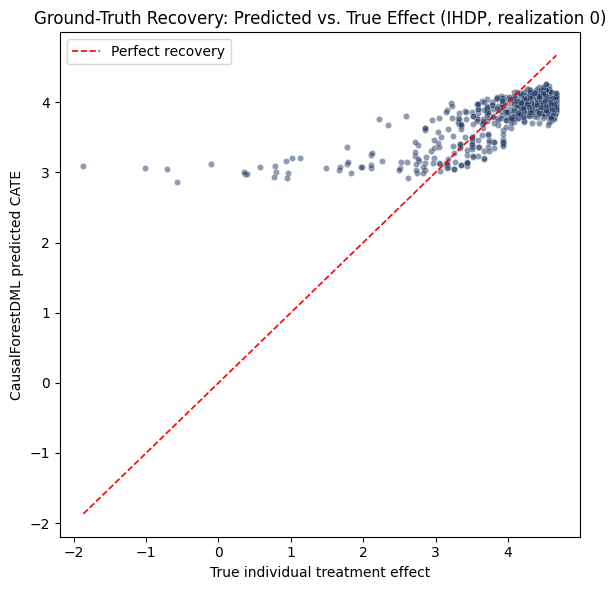

In [10]:
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
from econml.dml import CausalForestDML
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LogisticRegressionCV

urllib.request.urlretrieve(
    "https://www.fredjo.com/files/ihdp_npci_1-100.train.npz", "ihdp_train.npz")

train = np.load("ihdp_train.npz")
x, t, yf = train['x'][:, :, 0], train['t'][:, 0], train['yf'][:, 0]
mu0, mu1 = train['mu0'][:, 0], train['mu1'][:, 0]
true_ite = mu1 - mu0

cf = CausalForestDML(model_y=GradientBoostingRegressor(random_state=42),
                      model_t=LogisticRegressionCV(cv=5, random_state=42),
                      discrete_treatment=True, honest=True, min_samples_leaf=10,
                      n_estimators=1000, cv=5, random_state=42)
cf.fit(yf, t, X=x)
pred_ite = cf.effect(x)
print("PEHE:", np.sqrt(np.mean((pred_ite - true_ite)**2)))  # should now land at ~0.6174

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(true_ite, pred_ite, alpha=0.5, s=20, color="#1F3864", edgecolor="white", linewidth=0.3)
lims = [min(true_ite.min(), pred_ite.min()), max(true_ite.max(), pred_ite.max())]
ax.plot(lims, lims, 'r--', linewidth=1.2, label="Perfect recovery")
ax.set_xlabel("True individual treatment effect")
ax.set_ylabel("CausalForestDML predicted CATE")
ax.set_title("Ground-Truth Recovery: Predicted vs. True Effect (IHDP, realization 0)")
ax.legend()
plt.tight_layout()

from google.colab import drive
drive.mount('/content/drive')
plt.savefig('/content/drive/MyDrive/CausalMedia-GH/figure_error_analysis_ihdp.png', dpi=300, bbox_inches='tight')
print("Saved. PEHE this realization:", np.sqrt(np.mean((pred_ite - true_ite)**2)))

In [9]:
print(type(cf.model_y))

<class 'sklearn.ensemble._hist_gradient_boosting.gradient_boosting.HistGradientBoostingRegressor'>
